# Pseudobulk differential expression (PyDESeq2)

Sample-level pseudobulk DE for any **Level_3** cell type and biological covariate in `obs`.

- **DE:** `pseudobulk_de(adata, cell_type, covariate, ref_level=..., contrast_mode=...)`
- **ORA:** `pseudobulk_ora(result, test_level=..., gene_sets=...)`

**Supported covariates**
- `age_from_hsapdv`, `mapped_age_bin`: ordered age bins; default compares each bin vs a single reference (`contrast_mode="vs_reference"`), or vs all other bins pooled (`contrast_mode="vs_rest"`).
- `BMI`: continuous BMI binned (underweight / normal / overweight / obese).
- `BMI_category`: obese vs other (non-obese).
- `sex_ontology_term_id`: male vs female (PATO IDs).
- `development_stage_ontology_term_id`: old vs adult (HsapDv mapping).
- Any other categorical `obs` column: all levels with ≥ `min_samples_per_group` vs reference.


In [1]:
import os
import re
import warnings

import gseapy as gp
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)


/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/icb/daniel.strobl/.local/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `

In [2]:
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
H5AD_PATH = "/lustre/groups/ml01/workspace/hpca/hpca_downstream/2026_final_object_healthy_hierarchy.h5ad"
adata = sc.read_h5ad(H5AD_PATH)


In [4]:
adata_low_ambient = adata[adata.obs.high_ambient_rna == False]

In [5]:
adata.obs.groupby('donor_id').first().BMI_category.value_counts()

BMI_category
normal         31
obese          23
overweight     12
underweight     5
Name: count, dtype: int64

In [6]:
adata.obs.groupby('donor_id').first().BMI_category.value_counts()

BMI_category
normal         31
obese          23
overweight     12
underweight     5
Name: count, dtype: int64

In [20]:
from dataclasses import dataclass
from typing import Any

HSAPDV_LIFE_BIN = {
    "hsapdv:0000261": "young",
    "hsapdv:0000265": "young",
    "hsapdv:0000264": "young",
    "hsapdv:0000268": "young",
    "hsapdv:0000237": "adult",
    "hsapdv:0000238": "adult",
    "hsapdv:0000239": "adult",
    "hsapdv:0000240": "adult",
    "hsapdv:0000241": "old",
    "hsapdv:0000242": "old",
    "hsapdv:0000243": "old",
    "hsapdv:0000083": "young",
    "hsapdv:0000082": "young",
    "hsapdv:0000081": "young",
    "hsapdv:0000080": "adult",
    "hsapdv:0000084": "adult",
    "hsapdv:0000085": "adult",
    "hsapdv:0000086": "adult",
    "hsapdv:0000090": "adult",
    "hsapdv:0000087": "old",
    "hsapdv:0000088": "old",
    "hsapdv:0000089": "old",
}

BMI_BIN_ORDER = {"underweight": 0, "normal": 1, "overweight": 2, "obese": 3}


@dataclass
class PseudobulkDEResult:
    de_results: pd.DataFrame
    de_by_level: dict[str, pd.DataFrame]
    keep_levels: list[str]
    ref_level: str | None
    design_col: str
    contrast_info: dict[str, Any]
    cell_type: str
    covariate: str
    cell_level_col: str

    def save(self, path: str | None = None, dir_results: str = "./") -> str:
        if path is None:
            cell_stem = _sanitize_stem(self.cell_type)
            cov_stem = _sanitize_stem(self.covariate)
            path = os.path.join(dir_results, f"de_{cell_stem}__{cov_stem}_pseudobulk.csv")
        self.de_results.to_csv(path)
        print(f"Saved: {path}")
        return path

    def significant_log2fc(self, padj: float = 0.05) -> pd.DataFrame:
        if isinstance(self.de_results.index, pd.MultiIndex):
            return (
                self.de_results.query("padj < @padj")["log2FoldChange"]
                .unstack(level=1)
                .T
            )
        return (
            self.de_results.query("padj < @padj")
            .set_index("gene")[["log2FoldChange"]]
            .T
        )

    def run_ora(self, **kwargs) -> "PseudobulkORAResult":
        return pseudobulk_ora(self, **kwargs)


def _sanitize_stem(s: str) -> str:
    return re.sub(r"[^\w.-]+", "_", str(s).strip())


def _age_bin_order_key(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.startswith("("):
        return float(s.split(",")[0][1:])
    return np.nan


def _default_order_key(covariate, x):
    if covariate in ("age_from_hsapdv", "mapped_age_bin"):
        k = _age_bin_order_key(x)
        return k if not pd.isna(k) else np.inf
    if str(x) in BMI_BIN_ORDER:
        return BMI_BIN_ORDER[str(x)]
    try:
        return float(x)
    except (TypeError, ValueError):
        return str(x)


def map_bmi_obese_vs_other(x):
    if pd.isna(x):
        return None
    t = str(x).strip().lower()
    if t == "obese" or "obese" in t:
        return "obese"
    if t in ("normal", "overweight", "underweight"):
        return "other"
    return None


def map_bmi_who_bins(x):
    if pd.isna(x):
        return None
    v = float(x)
    if v < 18.5:
        return "underweight"
    if v < 25:
        return "normal"
    if v < 30:
        return "overweight"
    return "obese"


def _norm_ontology_token(s: str) -> str:
    s = str(s).strip().lower().replace(" ", "").replace("_", ":")
    if ":" not in s and len(s) > 6:
        for p in ("hsapdv", "uberon"):
            if s.startswith(p) and len(s) > len(p) and s[len(p)].isdigit():
                return f"{p}:{s[len(p):]}"
    return s


def bin_development_stage(x):
    if pd.isna(x):
        return None
    raw = str(x).strip()
    if not raw or raw.lower() == "nan":
        return None
    key = _norm_ontology_token(raw)
    if key in HSAPDV_LIFE_BIN:
        return HSAPDV_LIFE_BIN[key]
    low = raw.lower()
    if any(k in low for k in ("infant", "child", "juvenile", "adolescent", "pediatric", "neonat", "embryo", "fetal")):
        return "young"
    if any(k in low for k in ("elderly", "senior", "aged", "eighth decade", "ninth decade", "octogenarian")):
        return "old"
    if any(k in low for k in ("adult", "middle", "young adult", "thirt", "forti", "fift", "sixt")):
        return "adult"
    return None


def prepare_effect_column(raw_series, covariate):
    """Return (design_col, effect_series, mode, contrast_info)."""
    if covariate == "BMI_category":
        eff = raw_series.map(map_bmi_obese_vs_other)
        return (
            "BMI_obese_vs_other",
            eff,
            "binary",
            {"test": "obese", "ref": "other", "note": "obese vs other (non-obese)"},
        )
    if covariate == "BMI":
        eff = raw_series.map(map_bmi_who_bins)
        return (
            "BMI_binned",
            eff,
            "multi_level",
            {"order_key": lambda x: BMI_BIN_ORDER.get(str(x), 99), "note": "WHO BMI bins"},
        )
    if covariate == "sex_ontology_term_id":
        allowed = {"PATO:0000383", "PATO:0000384"}
        eff = raw_series.map(
            lambda x: str(x).strip() if pd.notna(x) and str(x).strip() in allowed else np.nan
        )
        return (
            covariate,
            eff,
            "binary",
            {"test": "PATO:0000384", "ref": "PATO:0000383", "note": "male vs female"},
        )
    if covariate == "development_stage_ontology_term_id":
        eff = raw_series.map(bin_development_stage)
        return (
            "development_life_stage",
            eff,
            "binary",
            {"test": "old", "ref": "adult", "note": "old vs adult"},
        )

    eff = raw_series.copy()
    if pd.api.types.is_numeric_dtype(eff):
        eff = eff.map(lambda x: str(x) if pd.notna(x) else np.nan)
    else:
        eff = eff.astype(str).replace({"nan": np.nan, "None": np.nan, "<NA>": np.nan})
    return (
        covariate,
        eff,
        "multi_level",
        {"order_key": lambda x: _default_order_key(covariate, x), "note": "all levels vs reference"},
    )


def aggregate_pseudobulk(
    adata_sub,
    covariate,
    min_cells_per_pb: int = 10,
    layer_key: str = "counts",
):
    if layer_key not in adata_sub.layers:
        raise KeyError(f"Layer '{layer_key}' missing; DESeq2 needs integer raw counts.")

    obs = adata_sub.obs.loc[adata_sub.obs[covariate].notna()].copy()
    X = adata_sub.layers[layer_key]

    sample_ids = []
    counts_list = []
    for sid, chunk in obs.groupby("ID", observed=True):
        if len(chunk) < min_cells_per_pb:
            continue
        pos = adata_sub.obs_names.get_indexer(chunk.index)
        pos = pos[pos >= 0]
        blk = X[pos]
        summed = np.asarray(blk.sum(axis=0)).ravel() if sparse.issparse(blk) else np.asarray(blk.sum(axis=0)).ravel()
        counts_list.append(summed)
        sample_ids.append(str(sid))

    if not counts_list:
        raise ValueError("No pseudobulk samples passed min_cells_per_pb filter.")

    counts_df = pd.DataFrame(np.stack(counts_list), index=sample_ids, columns=adata_sub.var_names)
    meta = (
        obs.assign(ID=obs["ID"].astype(str))
        .groupby("ID", observed=True)[["Dataset", covariate]]
        .first()
        .reindex(counts_df.index)
        .dropna(subset=[covariate])
    )
    counts_df = counts_df.loc[meta.index]
    return counts_df, meta


def _run_pseudobulk_de(
    adata_sub,
    covariate,
    ref_level=None,
    contrast_mode: str = "vs_reference",
    min_samples_per_group: int = 2,
    min_genes_detected: int = 10,
    min_cells_per_pb: int = 10,
    layer_key: str = "counts",
):
    if contrast_mode not in {"vs_reference", "vs_rest"}:
        raise ValueError(
            f"contrast_mode must be 'vs_reference' or 'vs_rest'; got {contrast_mode!r}"
        )
    counts_df, meta = aggregate_pseudobulk(
        adata_sub, covariate, min_cells_per_pb=min_cells_per_pb, layer_key=layer_key
    )
    design_col, eff, mode, contrast_info = prepare_effect_column(meta[covariate], covariate)
    meta = meta.copy()
    meta[design_col] = eff
    meta = meta.dropna(subset=[design_col])

    order_key = contrast_info.get("order_key", lambda x: _default_order_key(covariate, x))

    if contrast_mode == "vs_rest" and mode != "multi_level":
        raise ValueError(
            "contrast_mode='vs_rest' only applies to multi-level covariates "
            f"(got mode={mode!r} for {covariate!r})"
        )

    if mode == "binary":
        test_level = contrast_info["test"]
        ref = contrast_info["ref"]
        meta[design_col] = meta[design_col].astype(str).astype("category")
        meta["Dataset"] = meta["Dataset"].astype(str).astype("category")
        counts_df = counts_df.loc[meta.index]

        g_test = meta[design_col] == test_level
        g_ref = meta[design_col] == ref
        if g_test.sum() < min_samples_per_group or g_ref.sum() < min_samples_per_group:
            raise ValueError(
                f"Insufficient samples for {test_level} ({g_test.sum()}) or {ref} ({g_ref.sum()}); "
                f"need >= {min_samples_per_group} each."
            )
        if covariate == "sex_ontology_term_id":
            meta = meta.loc[g_test | g_ref].copy()
            counts_df = counts_df.loc[meta.index]

        cs = np.asarray(counts_df.sum(axis=0)).ravel()
        counts_df = counts_df.loc[:, counts_df.columns[cs >= min_genes_detected]]
        meta_dds = meta[["Dataset", design_col]].copy()

        print(f"Pseudobulk samples: {meta_dds.shape[0]}, genes: {counts_df.shape[1]}")
        print(meta_dds[design_col].value_counts())
        print(f"Contrast: {contrast_info['note']} ({test_level} vs {ref})")

        dds = DeseqDataSet(
            counts=counts_df.reset_index(drop=True),
            metadata=meta_dds.reset_index(drop=True),
            design_factors=["Dataset", design_col],
            refit_cooks=True,
            n_cpus=min(8, os.cpu_count() or 4),
        )
        dds.deseq2()

        stat_res = DeseqStats(dds, contrast=[design_col, test_level, ref])
        stat_res.summary()
        res = stat_res.results_df.copy()
        res["gene"] = counts_df.columns
        res["contrast"] = f"{test_level} vs {ref}"
        de_by_level = {test_level: res}
        de_results = res.copy()
        de_results["test_level"] = test_level
        keep_levels = [test_level, ref]
        return de_results, de_by_level, keep_levels, ref, design_col, contrast_info

    meta[design_col] = meta[design_col].astype(str)
    level_order = sorted(meta[design_col].unique(), key=order_key)
    vc = meta[design_col].value_counts()
    keep_levels = vc[vc >= min_samples_per_group].index.astype(str).tolist()
    if len(keep_levels) < 2:
        raise ValueError(f"Need >= 2 groups with >={min_samples_per_group} samples; have {vc.to_dict()}")

    if contrast_mode == "vs_rest":
        contrast_info = {**contrast_info, "contrast_mode": "vs_rest"}
    else:
        contrast_info = {**contrast_info, "contrast_mode": "vs_reference"}

    meta = meta.loc[meta[design_col].isin(keep_levels)]
    counts_df = counts_df.loc[meta.index]
    cats = [lvl for lvl in level_order if lvl in keep_levels]
    meta[design_col] = pd.Categorical(meta[design_col], categories=cats, ordered=True)
    meta["Dataset"] = meta["Dataset"].astype(str).astype("category")

    cs = np.asarray(counts_df.sum(axis=0)).ravel()
    counts_df = counts_df.loc[:, counts_df.columns[cs >= min_genes_detected]]

    print(f"Pseudobulk samples: {meta.shape[0]}, genes: {counts_df.shape[1]}")
    print(meta[design_col].value_counts().sort_index())

    de_by_level = {}
    n_cpus = min(8, os.cpu_count() or 4)

    if contrast_mode == "vs_rest":
        print("Contrast mode: each level vs all other levels (pooled)")
        rest_label = "other"
        contrast_col = "_one_vs_rest"
        for test_level in keep_levels:
            meta_loop = meta.copy()
            is_test = meta_loop[design_col].astype(str) == test_level
            meta_loop[contrast_col] = np.where(is_test, test_level, rest_label)
            n_test = int(is_test.sum())
            n_other = int((~is_test).sum())
            if n_test < min_samples_per_group or n_other < min_samples_per_group:
                print(
                    f"  skip {test_level}: insufficient samples "
                    f"(test={n_test}, other={n_other})"
                )
                continue
            meta_loop[contrast_col] = pd.Categorical(
                meta_loop[contrast_col], categories=[rest_label, test_level], ordered=True
            )
            meta_dds = meta_loop[["Dataset", contrast_col]].copy()
            dds = DeseqDataSet(
                counts=counts_df.reset_index(drop=True),
                metadata=meta_dds.reset_index(drop=True),
                design_factors=["Dataset", contrast_col],
                refit_cooks=True,
                n_cpus=n_cpus,
            )
            dds.deseq2()
            stat_res = DeseqStats(dds, contrast=[contrast_col, test_level, rest_label])
            stat_res.summary()
            res = stat_res.results_df.copy()
            res["gene"] = counts_df.columns
            res["contrast"] = f"{test_level} vs all other"
            de_by_level[test_level] = res
        if not de_by_level:
            raise ValueError("No contrasts passed min_samples_per_group in vs_rest mode.")
        ref = None
    else:
        ref = ref_level if ref_level in keep_levels else sorted(keep_levels, key=order_key)[0]
        print(f"Reference level: {ref}")
        meta_dds = meta[["Dataset", design_col]].copy()
        dds = DeseqDataSet(
            counts=counts_df.reset_index(drop=True),
            metadata=meta_dds.reset_index(drop=True),
            design_factors=["Dataset", design_col],
            ref_level=[design_col, ref],
            refit_cooks=True,
            n_cpus=n_cpus,
        )
        dds.deseq2()
        for test_level in [lvl for lvl in keep_levels if lvl != ref]:
            stat_res = DeseqStats(dds, contrast=[design_col, test_level, ref])
            stat_res.summary()
            res = stat_res.results_df.copy()
            res["gene"] = counts_df.columns
            res["contrast"] = f"{test_level} vs {ref}"
            de_by_level[test_level] = res

    de_results = pd.concat(de_by_level, names=["test_level"])
    return de_results, de_by_level, keep_levels, ref, design_col, contrast_info


def pseudobulk_de(
    adata,
    cell_type: str,
    covariate: str,
    ref_level: str | None = None,
    contrast_mode: str = "vs_reference",
    *,
    cell_level_col: str = "Level_3",
    min_cells_per_pb: int = 10,
    min_samples_per_group: int = 2,
    min_genes_detected: int = 10,
    layer_key: str = "counts",
) -> PseudobulkDEResult:
    """Pseudobulk DESeq2 for one cell type and biological covariate.

    Parameters
    ----------
    adata
        Full AnnData object.
    cell_type
        Value in ``cell_level_col`` to subset (e.g. ``"Beta Cell"``).
    covariate
        ``obs`` column name (e.g. ``"age_from_hsapdv"``, ``"BMI"``).
    ref_level
        Reference level for multi-level contrasts when ``contrast_mode="vs_reference"``;
        ``None`` picks the first ordered level. Ignored when ``contrast_mode="vs_rest"``
        and for binary covariates (``BMI_category``, sex, …).
    contrast_mode
        ``"vs_reference"`` (default): each level vs a single reference bin.
        ``"vs_rest"``: each level vs all other levels pooled (still adjusting for
        ``Dataset``). Useful for age bins when a fixed reference may confound cohort
        effects.
    """
    if cell_level_col not in adata.obs.columns:
        raise KeyError(f"Column '{cell_level_col}' not in adata.obs")
    if covariate not in adata.obs.columns:
        raise KeyError(f"Covariate '{covariate}' not in adata.obs")

    adata_sub = adata[adata.obs[cell_level_col] == cell_type].copy()
    print(f"{cell_type}: {adata_sub.n_obs:,} cells")
    if adata_sub.n_obs == 0:
        raise ValueError(f"No cells for {cell_level_col} == {cell_type!r}")

    de_results, de_by_level, keep_levels, ref, design_col, contrast_info = _run_pseudobulk_de(
        adata_sub,
        covariate,
        ref_level=ref_level,
        contrast_mode=contrast_mode,
        min_samples_per_group=min_samples_per_group,
        min_genes_detected=min_genes_detected,
        min_cells_per_pb=min_cells_per_pb,
        layer_key=layer_key,
    )

    return PseudobulkDEResult(
        de_results=de_results,
        de_by_level=de_by_level,
        keep_levels=keep_levels,
        ref_level=ref,
        design_col=design_col,
        contrast_info=contrast_info,
        cell_type=cell_type,
        covariate=covariate,
        cell_level_col=cell_level_col,
    )


DEFAULT_ORA_GENE_SETS = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
    "KEGG_2021_Human",
    "MSigDB_Hallmark_2020",
]


@dataclass
class PseudobulkORAResult:
    results: pd.DataFrame
    results_by_level: dict[str, pd.DataFrame]
    gene_lists: dict[str, list[str]]
    background_genes: list[str]
    gene_sets: list[str]
    cell_type: str
    covariate: str

    def save(self, path: str | None = None, dir_results: str = "./") -> str:
        if path is None:
            cell_stem = _sanitize_stem(self.cell_type)
            cov_stem = _sanitize_stem(self.covariate)
            path = os.path.join(dir_results, f"ora_{cell_stem}__{cov_stem}_enrichr.csv")
        self.results.to_csv(path)
        print(f"Saved: {path}")
        return path

    def top_terms(self, n: int = 10, padj_col: str = "Adjusted P-value") -> pd.DataFrame:
        if self.results.empty:
            return self.results
        df = self.results.copy()
        if isinstance(df.index, pd.MultiIndex):
            return (
                df.reset_index()
                .sort_values(padj_col)
                .groupby("test_level", group_keys=False)
                .head(n)
            )
        return df.sort_values(padj_col).head(n)


def _de_table_with_genes(de_table: pd.DataFrame) -> pd.DataFrame:
    df = de_table.copy()
    if "gene" not in df.columns:
        if isinstance(df.index, pd.MultiIndex):
            df = df.reset_index()
        elif df.index.name in ("gene", "gene_names") or df.index.name is None:
            df = df.reset_index().rename(columns={df.columns[0]: "gene"})
        else:
            df = df.reset_index()
    if "gene" not in df.columns:
        raise ValueError("Could not identify gene column in DE results.")
    return df


def de_significant_genes(
    de_table: pd.DataFrame,
    padj: float = 0.05,
    lfc_threshold: float = 0.0,
    direction: str | None = None,
) -> list[str]:
    """Extract significant gene symbols from one DE contrast table."""
    df = _de_table_with_genes(de_table)
    sig = df.loc[df["padj"] < padj].copy()
    if direction == "up":
        sig = sig.loc[sig["log2FoldChange"] > lfc_threshold]
    elif direction == "down":
        sig = sig.loc[sig["log2FoldChange"] < -lfc_threshold]
    elif lfc_threshold > 0:
        sig = sig.loc[sig["log2FoldChange"].abs() > lfc_threshold]
    genes = sig["gene"].dropna().astype(str).str.strip().unique().tolist()
    return [g for g in genes if g and g.lower() != "nan"]


def _background_genes_from_de(result: PseudobulkDEResult) -> list[str]:
    genes = []
    for de_table in result.de_by_level.values():
        df = _de_table_with_genes(de_table)
        genes.extend(df["gene"].dropna().astype(str).str.strip().tolist())
    return sorted(set(g for g in genes if g and g.lower() != "nan"))


def _run_enrichr(
    gene_list: list[str],
    gene_sets: list[str],
    organism: str = "human",
    background: list[str] | None = None,
    outdir: str | None = None,
    cutoff: float = 0.05,
) -> pd.DataFrame:
    kwargs = {
        "gene_list": gene_list,
        "gene_sets": gene_sets,
        "organism": organism,
        "outdir": outdir,
        "cutoff": cutoff,
        "no_plot": True,
    }
    if background is not None:
        kwargs["background"] = background
    enr = gp.enrichr(**kwargs)
    return enr.results.copy()


def pseudobulk_ora(
    result: PseudobulkDEResult,
    test_level: str | None = None,
    *,
    padj: float = 0.05,
    lfc_threshold: float = 0.0,
    direction: str | None = None,
    gene_sets: list[str] | None = None,
    organism: str = "human",
    background: list[str] | None = None,
    min_genes: int = 5,
    outdir: str | None = None,
    cutoff: float = 0.05,
) -> PseudobulkORAResult:
    """Over-representation analysis (Enrichr) on pseudobulk DE significant genes.

    Parameters
    ----------
    result
        Output of :func:`pseudobulk_de`.
    test_level
        Contrast level to test (e.g. ``"(70.0, 80.0)"``). ``None`` runs all contrasts.
    padj, lfc_threshold, direction
        Filters for selecting DE genes (``direction``: ``"up"``, ``"down"``, or ``None``).
    gene_sets
        Enrichr libraries; defaults to :data:`DEFAULT_ORA_GENE_SETS`.
    background
        Background gene list; defaults to all genes tested in the DE object.
    """
    if direction is not None and direction not in {"up", "down"}:
        raise ValueError("direction must be 'up', 'down', or None")

    gene_sets = list(gene_sets or DEFAULT_ORA_GENE_SETS)
    background_genes = background or _background_genes_from_de(result)
    levels = [test_level] if test_level is not None else list(result.de_by_level.keys())

    results_by_level: dict[str, pd.DataFrame] = {}
    gene_lists: dict[str, list[str]] = {}

    for level in levels:
        if level not in result.de_by_level:
            raise KeyError(
                f"test_level {level!r} not in result.de_by_level; "
                f"available: {list(result.de_by_level)}"
            )
        genes = de_significant_genes(
            result.de_by_level[level],
            padj=padj,
            lfc_threshold=lfc_threshold,
            direction=direction,
        )
        gene_lists[level] = genes
        print(f"{level}: {len(genes)} significant genes")
        if len(genes) < min_genes:
            print(f"  skip ORA (< {min_genes} genes)")
            continue

        ora_df = _run_enrichr(
            genes,
            gene_sets=gene_sets,
            organism=organism,
            background=background_genes,
            outdir=outdir,
            cutoff=cutoff,
        )
        ora_df["test_level"] = level
        ora_df["n_input_genes"] = len(genes)
        results_by_level[level] = ora_df

    if results_by_level:
        combined = pd.concat(results_by_level, names=["test_level"])
    else:
        combined = pd.DataFrame()

    return PseudobulkORAResult(
        results=combined,
        results_by_level=results_by_level,
        gene_lists=gene_lists,
        background_genes=background_genes,
        gene_sets=gene_sets,
        cell_type=result.cell_type,
        covariate=result.covariate,
    )



In [21]:
result = pseudobulk_de(
    adata_low_ambient,
    cell_type="Beta Cell",
    covariate="age_from_hsapdv",
    contrast_mode="vs_rest",
)

# Other examples:
# result = pseudobulk_de(adata, "Beta Cell", "age_from_hsapdv", ref_level="(30.0, 40.0)")  # vs one reference
# result = pseudobulk_de(adata, "Alpha Cell", "BMI", ref_level="normal")
# result = pseudobulk_de(adata, "Beta Cell", "BMI_category")



Beta Cell: 46,797 cells
Pseudobulk samples: 146, genes: 21105
age_from_hsapdv
(1.0, 5.0)       3
(5.0, 15.0)      7
(15.0, 20.0)     2
(20.0, 30.0)    17
(30.0, 40.0)    13
(40.0, 50.0)    25
(50.0, 60.0)    49
(60.0, 70.0)    19
(70.0, 80.0)    11
Name: count, dtype: int64
Contrast mode: each level vs all other levels (pooled)


/tmp/ipykernel_1228681/579080170.py:360: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.86 seconds.

Fitting dispersion trend curve...
... done in 0.68 seconds.

Fitting MAP dispersions...
... done in 7.02 seconds.

Fitting LFCs...
... done in 5.64 seconds.

Calculating cook's distance...
... done in 0.30 seconds.

Replacing 27 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...
... done in 244.19 seconds.



Log2 fold change & Wald test p-value: _one_vs_rest (50.0, 60.0) vs other
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
7SK           0.112639       -0.023696  3.468903 -0.006831  0.994550       NaN
A1BG        127.478214       -0.041647  0.112402 -0.370516  0.710998  0.949541
A1BG-AS1     15.845615       -0.180436  0.097055 -1.859115  0.063011  0.499116
A1CF         51.324586       -0.066615  0.131193 -0.507762  0.611620  0.925968
A2M           1.613048        0.626429  0.298028  2.101916  0.035561  0.420025
...                ...             ...       ...       ...       ...       ...
ZYG11A        1.438975        0.097731  0.334059  0.292555  0.769863  0.962232
ZYG11B       62.933239        0.076182  0.072583  1.049572  0.293915  0.771734
ZYX          14.094879        0.221840  0.212332  1.044777  0.296126  0.773948
ZZEF1        70.675294       -0.022653  0.065243 -0.347214

...

Log2 fold change & Wald test p-value: _one_vs_rest (1.0, 5.0) vs other
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
gene_names                                                              
7SK           0.112639        0.078141  11.248080  0.006947  0.994457   
A1BG        127.478214        0.002139   0.293649  0.007284  0.994189   
A1BG-AS1     15.845615       -0.103430   0.262420 -0.394139  0.693478   
A1CF         51.324586       -0.008231   0.462011 -0.017816  0.985786   
A2M           1.613048       -1.275095   0.969211 -1.315602  0.188308   
...                ...             ...        ...       ...       ...   
ZYG11A        1.438975       -0.065614   0.805721 -0.081435  0.935096   
ZYG11B       62.933239       -0.605322   0.219097 -2.762801  0.005731   
ZYX          14.094879       -0.477325   0.546080 -0.874093  0.382067   
ZZEF1        70.675294       -0.329642   0.207637 -1.587587  0.112380   
ZZZ3          5.714160       -0.018486   2.534741 -0.

/tmp/ipykernel_1228681/579080170.py:360: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.08 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.08 seconds.

Fitting dispersion trend curve...
... done in 0.59 seconds.

Fitting MAP dispersions...
... done in 6.35 seconds.

Fitting LFCs...
... done in 5.35 seconds.

Calculating cook's distance...
... done in 0.21 seconds.

Replacing 20 outlier genes.

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...
... done in 245.97 seconds.



Log2 fold change & Wald test p-value: _one_vs_rest (15.0, 20.0) vs other
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
gene_names                                                              
7SK           0.112639        0.295744  13.796848  0.021436  0.982898   
A1BG        127.478214        0.341441   0.490440  0.696193  0.486308   
A1BG-AS1     15.845615       -0.186698   0.427479 -0.436742  0.662298   
A1CF         51.324586       -0.123622   0.546260 -0.226306  0.820963   
A2M           1.613048       -0.150457   1.249110 -0.120451  0.904126   
...                ...             ...        ...       ...       ...   
ZYG11A        1.438975        0.730469   0.906241  0.806043  0.420218   
ZYG11B       62.933239       -0.145070   0.306513 -0.473290  0.636006   
ZYX          14.094879       -0.685498   0.873981 -0.784339  0.432841   
ZZEF1        70.675294       -0.103238   0.261081 -0.395423  0.692531   
ZZZ3          5.714160        0.309767   3.642116  

In [43]:
result_against_30 = pseudobulk_de(
    adata_low_ambient,
    cell_type="Beta Cell",
    covariate="age_from_hsapdv",
    ref_level="(30.0, 40.0)",
)

# Other examples:
# result = pseudobulk_de(adata, "Beta Cell", "age_from_hsapdv", ref_level="(30.0, 40.0)")  # vs one reference
# result = pseudobulk_de(adata, "Alpha Cell", "BMI", ref_level="normal")
# result = pseudobulk_de(adata, "Beta Cell", "BMI_category")



Beta Cell: 46,797 cells
Pseudobulk samples: 146, genes: 21105
age_from_hsapdv
(1.0, 5.0)       3
(5.0, 15.0)      7
(15.0, 20.0)     2
(20.0, 30.0)    17
(30.0, 40.0)    13
(40.0, 50.0)    25
(50.0, 60.0)    49
(60.0, 70.0)    19
(70.0, 80.0)    11
Name: count, dtype: int64
Reference level: (30.0, 40.0)


/tmp/ipykernel_1228681/579080170.py:381: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_1228681/579080170.py:381: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.11 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 7.25 seconds.

Fitting dispersion trend curve...
... done in 0.65 seconds.

Fitting MAP dispersions...
... done in 7.13 seconds.

Fitting LFCs...
... done in 7.79 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 150 outlier genes.

Fitting dispersions...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.08 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 245.53 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (50.0, 60.0) vs (30.0, 40.0)
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
7SK           0.112639       -0.949867  7.006458 -0.135570  0.892161       NaN
A1BG        127.478214       -0.256891  0.196618 -1.306547  0.191367  0.614727
A1BG-AS1     15.845615       -0.266046  0.182065 -1.461269  0.143942  0.562833
A1CF         51.324586       -0.161357  0.291790 -0.552992  0.580269  0.863459
A2M           1.613048        0.554755  0.645860  0.858940  0.390374       NaN
...                ...             ...       ...       ...       ...       ...
ZYG11A        1.438975        0.062244  0.675118  0.092197  0.926542       NaN
ZYG11B       62.933239        0.241089  0.142605  1.690615  0.090910  0.472576
ZYX          14.094879       -0.650936  0.360382 -1.806239  0.070881  0.431855
ZZEF1        70.675294        0.299735  0.127498

...

Log2 fold change & Wald test p-value: age_from_hsapdv (5.0, 15.0) vs (30.0, 40.0)
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
7SK           0.112639        1.701375  9.256233  0.183809  0.854164       NaN
A1BG        127.478214       -0.106837  0.303932 -0.351515  0.725202  0.979757
A1BG-AS1     15.845615        0.203420  0.301710  0.674226  0.500168  0.933355
A1CF         51.324586        0.183950  0.428916  0.428872  0.668017  0.972597
A2M           1.613048       -0.526683  1.161708 -0.453369  0.650283       NaN
...                ...             ...       ...       ...       ...       ...
ZYG11A        1.438975        0.613107  1.414323  0.433499  0.664652       NaN
ZYG11B       62.933239        0.082058  0.214380  0.382768  0.701892  0.977457
ZYX          14.094879       -0.817226  0.599452 -1.363288  0.172792  0.791848
ZZEF1        70.675294        0.551613  0.186509 

Running Wald tests...
... done in 4.20 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (1.0, 5.0) vs (30.0, 40.0)
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
gene_names                                                              
7SK           0.112639       -0.312814  11.897649 -0.026292  0.979024   
A1BG        127.478214       -0.112338   0.316085 -0.355403  0.722288   
A1BG-AS1     15.845615       -0.207317   0.282512 -0.733836  0.463049   
A1CF         51.324586       -0.034043   0.500282 -0.068048  0.945747   
A2M           1.613048       -1.036100   1.029563 -1.006350  0.314247   
...                ...             ...        ...       ...       ...   
ZYG11A        1.438975        0.049236   0.965650  0.050988  0.959335   
ZYG11B       62.933239       -0.458757   0.232977 -1.969105  0.048941   
ZYX          14.094879       -0.929344   0.588646 -1.578782  0.114386   
ZZEF1        70.675294       -0.118118   0.207557 -0.569089  0.569296   
ZZZ3          5.714160       -0.235377  11.

Running Wald tests...
... done in 4.26 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (15.0, 20.0) vs (30.0, 40.0)
              baseMean  log2FoldChange      lfcSE      stat    pvalue  padj
gene_names                                                                 
7SK           0.112639        0.127853  14.637310  0.008735  0.993031   1.0
A1BG        127.478214        0.209689   0.511362  0.410061  0.681762   1.0
A1BG-AS1     15.845615       -0.315572   0.443084 -0.712217  0.476330   1.0
A1CF         51.324586       -0.103060   0.595563 -0.173046  0.862616   1.0
A2M           1.613048        0.088992   1.239586  0.071792  0.942768   1.0
...                ...             ...        ...       ...       ...   ...
ZYG11A        1.438975        0.826936   1.114586  0.741922  0.458135   1.0
ZYG11B       62.933239        0.014169   0.310562  0.045625  0.963609   1.0
ZYX          14.094879       -1.049336   0.912578 -1.149858  0.250202   1.0
ZZEF1        70.675294        0.158241   0.256763  0.616291  0.537703   1.0
ZZZ3 

In [50]:
result_against_20 = pseudobulk_de(
    adata_low_ambient,
    cell_type="Beta Cell",
    covariate="age_from_hsapdv",
    ref_level="(20.0, 30.0)",
)

# Other examples:
# result = pseudobulk_de(adata, "Beta Cell", "age_from_hsapdv", ref_level="(30.0, 40.0)")  # vs one reference
# result = pseudobulk_de(adata, "Alpha Cell", "BMI", ref_level="normal")
# result = pseudobulk_de(adata, "Beta Cell", "BMI_category")



Beta Cell: 46,797 cells
Pseudobulk samples: 146, genes: 21105
age_from_hsapdv
(1.0, 5.0)       3
(5.0, 15.0)      7
(15.0, 20.0)     2
(20.0, 30.0)    17
(30.0, 40.0)    13
(40.0, 50.0)    25
(50.0, 60.0)    49
(60.0, 70.0)    19
(70.0, 80.0)    11
Name: count, dtype: int64
Reference level: (20.0, 30.0)


/tmp/ipykernel_1228681/579080170.py:381: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_1228681/579080170.py:381: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.08 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.95 seconds.

Fitting dispersion trend curve...
... done in 0.78 seconds.

Fitting MAP dispersions...
... done in 10.26 seconds.

Fitting LFCs...
... done in 7.47 seconds.

Calculating cook's distance...
... done in 0.39 seconds.

Replacing 150 outlier genes.

Fitting dispersions...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 244.62 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (50.0, 60.0) vs (20.0, 30.0)
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
7SK           0.112639       -0.506380  7.085563 -0.071466  0.943027       NaN
A1BG        127.478214       -0.015996  0.199876 -0.080028  0.936215  0.986925
A1BG-AS1     15.845615       -0.103348  0.172039 -0.600727  0.548022  0.886762
A1CF         51.324586       -0.373343  0.282372 -1.322166  0.186113  0.668873
A2M           1.613048        0.941837  0.650466  1.447941  0.147633       NaN
...                ...             ...       ...       ...       ...       ...
ZYG11A        1.438975       -0.445311  0.700137 -0.636033  0.524755       NaN
ZYG11B       62.933239        0.024534  0.137270  0.178724  0.858154  0.979328
ZYX          14.094879       -0.058430  0.366569 -0.159398  0.873356  0.982527
ZZEF1        70.675294        0.000325  0.120022

...

Log2 fold change & Wald test p-value: age_from_hsapdv (5.0, 15.0) vs (20.0, 30.0)
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
7SK           0.112639        2.144863  8.618637  0.248863  0.803466       NaN
A1BG        127.478214        0.134059  0.309860  0.432642  0.665275  0.894438
A1BG-AS1     15.845615        0.366118  0.293033  1.249408  0.211516       NaN
A1CF         51.324586       -0.028036  0.396465 -0.070715  0.943624  0.983492
A2M           1.613048       -0.139601  1.087487 -0.128370  0.897856       NaN
...                ...             ...       ...       ...       ...       ...
ZYG11A        1.438975        0.105553  1.260274  0.083754  0.933252       NaN
ZYG11B       62.933239       -0.134498  0.201093 -0.668835  0.503601  0.824674
ZYX          14.094879       -0.224721  0.605954 -0.370854  0.710746       NaN
ZZEF1        70.675294        0.252202  0.170954 

Running Wald tests...
... done in 4.62 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (1.0, 5.0) vs (20.0, 30.0)
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
gene_names                                                              
7SK           0.112639        0.130673  12.247625  0.010669  0.991487   
A1BG        127.478214        0.128558   0.326667  0.393544  0.693918   
A1BG-AS1     15.845615       -0.044620   0.288196 -0.154824  0.876960   
A1CF         51.324586       -0.246029   0.511953 -0.480570  0.630822   
A2M           1.613048       -0.649018   1.079895 -0.601001  0.547839   
...                ...             ...        ...       ...       ...   
ZYG11A        1.438975       -0.458318   1.019751 -0.449441  0.653113   
ZYG11B       62.933239       -0.675313   0.237870 -2.839004  0.004525   
ZYX          14.094879       -0.336838   0.608142 -0.553881  0.579661   
ZZEF1        70.675294       -0.417528   0.210150 -1.986810  0.046943   
ZZZ3          5.714160        0.351227  12.

Running Wald tests...
... done in 4.79 seconds.



Log2 fold change & Wald test p-value: age_from_hsapdv (15.0, 20.0) vs (20.0, 30.0)
              baseMean  log2FoldChange      lfcSE      stat    pvalue  \
gene_names                                                              
7SK           0.112639        0.571340  14.424835  0.039608  0.968406   
A1BG        127.478214        0.450585   0.521529  0.863970  0.387605   
A1BG-AS1     15.845615       -0.152875   0.449223 -0.340309  0.733624   
A1CF         51.324586       -0.315045   0.587968 -0.535821  0.592082   
A2M           1.613048        0.476074   1.265988  0.376049  0.706880   
...                ...             ...        ...       ...       ...   
ZYG11A        1.438975        0.319382   1.184062  0.269734  0.787365   
ZYG11B       62.933239       -0.202386   0.309813 -0.653253  0.513593   
ZYX          14.094879       -0.456830   0.932863 -0.489707  0.624341   
ZZEF1        70.675294       -0.141169   0.255430 -0.552674  0.580487   
ZZZ3          5.714160        0.581846  1

In [64]:
result.significant_log2fc().to_csv("/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/beta_age_significant_genes_without_ambient.csv")

In [60]:
result.save(dir_results="./")

order_key = result.contrast_info.get(
    "order_key", lambda x: _default_order_key(result.covariate, x)
)
if len(result.de_by_level) == 1:
    top_level = next(iter(result.de_by_level))
else:
    top_level = sorted(
        [lvl for lvl in result.keep_levels if lvl != result.ref_level],
        key=order_key,
    )[-1]

display(
    result.de_by_level[top_level]
    .query("padj < 0.05")
    .sort_values("log2FoldChange", ascending=False)
    .head(20)
)


Saved: ./de_Beta_Cell__age_from_hsapdv_pseudobulk.csv


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,contrast
gene_names,,,,,,,,
NTNG1,11.381511,3.198926,0.672524,4.756594,1.968866e-06,2.687502e-03,NTNG1,"(70.0, 80.0) vs (30.0, 40.0)"
ENPP2,265.367657,2.335513,0.300583,7.769943,7.852129e-15,1.071816e-10,ENPP2,"(70.0, 80.0) vs (30.0, 40.0)"
FOS,480.806354,2.074671,0.517489,4.009113,6.094722e-05,2.179428e-02,FOS,"(70.0, 80.0) vs (30.0, 40.0)"
EGR1,165.371963,1.876043,0.414820,4.522552,6.109861e-06,4.905859e-03,EGR1,"(70.0, 80.0) vs (30.0, 40.0)"
DPYSL3,31.538553,1.685189,0.436765,3.858339,1.141604e-04,2.804705e-02,DPYSL3,"(70.0, 80.0) vs (30.0, 40.0)"
ADAMTSL4-AS1,21.576090,1.663976,0.384449,4.328212,1.503249e-05,7.892056e-03,ADAMTSL4-AS1,"(70.0, 80.0) vs (30.0, 40.0)"
RNF19A,108.921622,1.499426,0.199753,7.506418,6.076711e-14,4.147355e-10,RNF19A,"(70.0, 80.0) vs (30.0, 40.0)"
RAB11FIP1,207.284065,1.332603,0.227589,5.855317,4.761014e-09,1.624696e-05,RAB11FIP1,"(70.0, 80.0) vs (30.0, 40.0)"
SGMS2,102.039609,1.331650,0.271515,4.904519,9.365679e-07,1.907594e-03,SGMS2,"(70.0, 80.0) vs (30.0, 40.0)"


In [ ]:
# ORA on one contrast (uses top_level from previous cell)
ora_result = result.run_ora(
    test_level=top_level,
    padj=0.05,
    direction="up",  # or "down", or None for both
)

ora_result.top_terms(n=10)


In [ ]:
ora_result.save(dir_results="./")

# All contrasts:
# ora_all = pseudobulk_ora(result, test_level=None)
# ora_all.save()


In [45]:
significant_genes = result_against_30.significant_log2fc()
significant_genes.shape


(784, 7)

In [46]:
if significant_genes.shape[1] > 1 and result.covariate not in (
    "BMI_category",
    "sex_ontology_term_id",
    "development_stage_ontology_term_id",
):
    order_key = result.contrast_info.get(
        "order_key", lambda x: _default_order_key(result.covariate, x)
    )
    ordered_cols = sorted(
        [c for c in significant_genes.columns if c != result.ref_level],
        key=order_key,
    )
    significant_genes = significant_genes.loc[:, ordered_cols]
significant_genes.columns


Index(['(1.0, 5.0)', '(5.0, 15.0)', '(20.0, 30.0)', '(40.0, 50.0)',
       '(50.0, 60.0)', '(60.0, 70.0)', '(70.0, 80.0)'],
      dtype='object', name='test_level')

In [47]:
significant_genes.head(20)


test_level,"(1.0, 5.0)","(5.0, 15.0)","(20.0, 30.0)","(40.0, 50.0)","(50.0, 60.0)","(60.0, 70.0)","(70.0, 80.0)"
gene_names,,,,,,,
ABR,NaN,NaN,-0.832850,-0.892611,-0.745022,-0.782530,-1.078853
ACAP2,NaN,NaN,NaN,NaN,0.410733,NaN,NaN
ACTR3B,NaN,NaN,NaN,NaN,-0.715659,NaN,NaN
ADTRP,NaN,NaN,NaN,NaN,-1.810895,NaN,NaN
ALG11,1.686276,NaN,1.114521,0.827387,0.860824,0.905201,NaN
ANK1,-2.552561,NaN,-1.750240,-1.929757,-1.345037,NaN,NaN
ANPEP,NaN,NaN,NaN,-2.204099,-2.839130,-2.848483,-2.866687
APC,0.760440,NaN,NaN,NaN,0.503803,NaN,NaN
ARFRP1,NaN,NaN,-1.223285,NaN,-0.930141,-1.235480,-1.210861


In [48]:
from scipy.stats import spearmanr


def _age_bin_midpoint(bin_label):
    lo, hi = str(bin_label).strip("()").split(",")
    return (float(lo) + float(hi)) / 2


def genes_changing_across_time(
    sig_log2fc: pd.DataFrame,
    result: PseudobulkDEResult,
    min_bins: int = 2,
    min_abs_spearman: float = 0.1,
    max_spearman_p: float = 0.05,
) -> pd.DataFrame:
    """Rank genes by monotonic trend across ordered contrast columns."""
    order_key = result.contrast_info.get(
        "order_key", lambda x: _default_order_key(result.covariate, x)
    )
    cols = sorted(
        [c for c in sig_log2fc.columns if c != result.ref_level],
        key=order_key,
    )
    mat = sig_log2fc.loc[:, cols]
    ages = np.array([_age_bin_midpoint(b) for b in cols])

    records = []
    for gene, row in mat.iterrows():
        y = row.to_numpy(dtype=float)
        mask = ~np.isnan(y)
        n = int(mask.sum())
        if n < min_bins:
            continue
        r, p = spearmanr(ages[mask], y[mask])
        records.append(
            {
                "gene": gene,
                "spearman_r": r,
                "spearman_p": p,
                "n_bins": n,
                "direction": "up" if r > 0 else "down",
            }
        )
    trends = pd.DataFrame(records).set_index("gene")
    return trends.query(
        "spearman_p <= @max_spearman_p & spearman_r.abs() >= @min_abs_spearman"
    ).sort_values("spearman_r", ascending=False)


In [49]:
age_trends = genes_changing_across_time(significant_genes, result)
print(f"{len(age_trends)} genes with consistent age trend")
print(f"  up with age:   {(age_trends['direction'] == 'up').sum()}")
print(f"  down with age: {(age_trends['direction'] == 'down').sum()}")
age_trends.join(significant_genes).head(20)


32 genes with consistent age trend
  up with age:   14
  down with age: 18


,spearman_r,spearman_p,n_bins,direction,"(1.0, 5.0)","(5.0, 15.0)","(20.0, 30.0)","(40.0, 50.0)","(50.0, 60.0)","(60.0, 70.0)","(70.0, 80.0)"
gene,,,,,,,,,,,
RGL3,1.000000,0.000000e+00,3,up,-1.221173,NaN,NaN,NaN,NaN,-0.988822,-0.897104
CUZD1,1.000000,0.000000e+00,4,up,NaN,NaN,NaN,-4.828220,-4.453375,-4.405490,-4.253502
RARA,1.000000,0.000000e+00,3,up,-1.279119,NaN,-0.777072,NaN,-0.763063,NaN,NaN
KIAA1958,1.000000,0.000000e+00,3,up,NaN,NaN,0.655938,NaN,0.685955,NaN,1.235126
HSPA8,1.000000,0.000000e+00,4,up,-1.486454,NaN,-1.372419,-1.091048,-1.024905,NaN,NaN
FRS2,1.000000,0.000000e+00,3,up,NaN,NaN,0.498815,NaN,0.529107,NaN,0.739864
DNAJB1,1.000000,0.000000e+00,3,up,-2.417302,NaN,NaN,-1.687585,-1.466749,NaN,NaN
RAB12,1.000000,0.000000e+00,3,up,NaN,NaN,0.851864,0.865625,NaN,0.985358,NaN
MICAL1,1.000000,0.000000e+00,3,up,NaN,NaN,-1.322928,NaN,NaN,-1.189522,-1.184912


In [38]:
significant_genes.loc[beta_aging_program["age_up_beta"]+beta_aging_program["age_down_beta"]]

test_level,"(1.0, 5.0)","(5.0, 15.0)","(20.0, 30.0)","(30.0, 40.0)","(40.0, 50.0)","(50.0, 60.0)","(60.0, 70.0)","(70.0, 80.0)"
gene_names,,,,,,,,
SPP1,-5.841123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DGKB,-5.128757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DLEU2,NaN,NaN,NaN,0.696999,NaN,NaN,NaN,NaN
MYO3A,NaN,NaN,NaN,0.495920,NaN,NaN,NaN,NaN
LSAMP,-2.476775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PAPSS2,-1.672953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIAM1,-1.259855,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
significant_genes.sort_values(by='(70.0, 80.0)', ascending=False)[:40]

test_level,"(1.0, 5.0)","(5.0, 15.0)","(20.0, 30.0)","(30.0, 40.0)","(40.0, 50.0)","(50.0, 60.0)","(60.0, 70.0)","(70.0, 80.0)"
gene_names,,,,,,,,
ENPP2,NaN,NaN,NaN,NaN,NaN,-1.066028,NaN,2.521575
HSPA1A,NaN,NaN,NaN,1.644535,NaN,NaN,NaN,2.035356
FOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.030638
NTNG1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.004688
TEKT1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.940905
GLIPR2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.933656
CNTNAP3B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.641751
DPYSL3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.638982
HSPA1B,NaN,NaN,NaN,2.023506,NaN,NaN,NaN,1.610029


In [8]:
result_macrophage_bmi = pseudobulk_de(adata, "Macrophage", "BMI", ref_level="normal")

Macrophage: 5,240 cells
Pseudobulk samples: 89, genes: 16453
BMI_binned
underweight     5
normal         25
overweight     34
obese          25
Name: count, dtype: int64
Reference level: normal


/tmp/ipykernel_2164524/3371038033.py:324: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_2164524/3371038033.py:324: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.13 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 4.21 seconds.

Fitting dispersion trend curve...
... done in 0.42 seconds.

Fitting MAP dispersions...
... done in 3.99 seconds.

Fitting LFCs...
... done in 3.99 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 32 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...
... done in 7.70 seconds.



Log2 fold change & Wald test p-value: BMI_binned overweight vs normal
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                   
A1BG         3.014162       -0.174899  0.449711 -0.388915  0.697339       NaN
A1BG-AS1     0.988437        0.412146  0.506120  0.814325  0.415459       NaN
A1CF         1.243467       -0.468499  0.633555 -0.739477  0.459618       NaN
A2M         15.277537        1.075194  0.263204  4.085021  0.000044  0.014800
A2M-AS1      0.112135       -0.052495  1.034586 -0.050740  0.959532       NaN
...               ...             ...       ...       ...       ...       ...
ZYG11A       0.092227       -0.422163  2.812659 -0.150094  0.880690       NaN
ZYG11B       6.303815        0.144396  0.196957  0.733136  0.463476  0.810957
ZYX          7.860317        0.463291  0.266939  1.735565  0.082641  0.445657
ZZEF1       12.286353        0.219123  0.177475  1.234670  0.216953  0.6

Running Wald tests...
... done in 1.34 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: BMI_binned obese vs normal
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                   
A1BG         3.014162       -0.528038  0.426821 -1.237143  0.216034       NaN
A1BG-AS1     0.988437        0.634285  0.523537  1.211536  0.225690       NaN
A1CF         1.243467        0.202170  0.637383  0.317188  0.751101       NaN
A2M         15.277537        0.301056  0.274302  1.097536  0.272407  0.708423
A2M-AS1      0.112135       -0.019928  1.099919 -0.018117  0.985545       NaN
...               ...             ...       ...       ...       ...       ...
ZYG11A       0.092227        0.105602  2.888454  0.036560  0.970836       NaN
ZYG11B       6.303815       -0.036764  0.211731 -0.173634  0.862153  0.969908
ZYX          7.860317        0.234170  0.276578  0.846668  0.397180  0.786691
ZZEF1       12.286353       -0.067641  0.191628 -0.352979  0.724104  0.926026

... done in 1.50 seconds.



In [9]:
result_acinar_bmi = pseudobulk_de(adata, "Acinar Cell", "BMI", ref_level="normal")

Acinar Cell: 416,161 cells
Pseudobulk samples: 139, genes: 20931
BMI_binned
underweight     9
normal         43
overweight     42
obese          45
Name: count, dtype: int64
Reference level: normal


/tmp/ipykernel_2164524/3371038033.py:324: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/tmp/ipykernel_2164524/3371038033.py:324: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.19 seconds.

Fitting dispersion trend curve...
... done in 0.70 seconds.

Fitting MAP dispersions...
... done in 5.96 seconds.

Fitting LFCs...
... done in 5.37 seconds.

Calculating cook's distance...
... done in 0.17 seconds.

Replacing 11623 outlier genes.

Fitting dispersions...
... done in 2.70 seconds.

Fitting MAP dispersions...
... done in 3.12 seconds.

Fitting LFCs...
... done in 3.07 seconds.

Running Wald tests...
... done in 8.35 seconds.



Log2 fold change & Wald test p-value: BMI_binned obese vs normal
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
A1BG         40.381188       -0.336150  0.264483 -1.270972  0.203739  0.602027
A1BG-AS1      7.831721        0.129387  0.281827  0.459100  0.646162  0.900991
A1CF        435.557624        0.238829  0.146827  1.626605  0.103821  0.455163
A2M          18.395076        0.153473  0.289424  0.530268  0.595926  0.878302
A2M-AS1       2.896578       -0.091287  0.192133 -0.475123  0.634699  0.894172
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.424355        0.123700  0.278162  0.444705  0.656533  0.905855
ZYG11B      226.744107        0.031707  0.070229  0.451487  0.651639  0.903466
ZYX          99.295563        0.096105  0.131801  0.729170  0.465898  0.811333
ZZEF1       402.415577       -0.106310  0.069473 -1.530222  0.1259

Running Wald tests...
... done in 1.93 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: BMI_binned overweight vs normal
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
A1BG         40.381188       -0.026555  0.277776 -0.095597  0.923840  0.984244
A1BG-AS1      7.831721        0.615228  0.286082  2.150529  0.031513  0.223314
A1CF        435.557624        0.229869  0.151168  1.520622  0.128355  0.435924
A2M          18.395076        0.370640  0.295642  1.253678  0.209959  0.548528
A2M-AS1       2.896578       -0.169680  0.194868 -0.870742  0.383895  0.710365
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.424355       -0.132031  0.280011 -0.471520  0.637269  0.870298
ZYG11B      226.744107       -0.008632  0.071944 -0.119979  0.904499  0.979571
ZYX          99.295563        0.196698  0.137761  1.427822  0.153343  0.472984
ZZEF1       402.415577       -0.185015  0.070519 -2.623613  0

... done in 1.88 seconds.



Log2 fold change & Wald test p-value: BMI_binned underweight vs normal
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_names                                                                    
A1BG         40.381188       -0.545947  0.441387 -1.236889  0.216128  0.579553
A1BG-AS1      7.831721       -0.417470  0.464836 -0.898102  0.369131  0.722741
A1CF        435.557624        0.518506  0.237617  2.182107  0.029102  0.218622
A2M          18.395076       -0.642035  0.478816 -1.340881  0.179959  0.533974
A2M-AS1       2.896578       -0.103792  0.297175 -0.349260  0.726894  0.915590
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.424355        0.166365  0.480542  0.346204  0.729190  0.916471
ZYG11B      226.744107       -0.185188  0.112599 -1.644675  0.100037  0.407273
ZYX          99.295563       -0.352670  0.218746 -1.612235  0.106911  0.421856
ZZEF1       402.415577       -0.047696  0.110576 -0.431343  

In [10]:
result_macrophage_bmi.significant_log2fc().sort_values(by="obese", ascending=False)[:20]

test_level,overweight,obese,underweight
gene_names,,,
CENPF,NaN,2.945087,NaN
DIAPH3,NaN,2.497036,NaN
C3,2.449889,2.344100,NaN
SORL1,NaN,1.504703,NaN
LAMTOR5-AS1,NaN,1.390977,NaN
MACC1,NaN,1.380363,NaN
ZNF804A,NaN,1.372258,NaN
LTA4H,NaN,1.281486,1.646168
SLBP,NaN,1.131260,NaN


In [10]:
result_acinar_bmi.de_by_level["obese"].sort_values(by="log2FoldChange", ascending=False).query('padj<0.05 and log2FoldChange>0').sort_values(by='log2FoldChange', ascending=False).gene.tolist()

['FGG',
 'FGA',
 'CRP',
 'ANTXR1',
 'LINC01291',
 'CCL2',
 'CXCL1',
 'TNFSF14',
 'CXCL8',
 'CXCL3',
 'PMFBP1',
 'DNAH5',
 'SERPINA1',
 'PNLDC1',
 'FN1',
 'ZNF385B',
 'HPX',
 'GBP1',
 'RGS5',
 'LGALS9',
 'LINC02770',
 'FGL1',
 'LINC02347',
 'PSMB9',
 'WFIKKN1',
 'LAMA3',
 'HCLS1',
 'FSTL3',
 'GALNT18',
 'TMEM265',
 'RNASEH2B-AS1',
 'CNDP1',
 'NUMBL',
 'PCSK6',
 'PLK1',
 'AVIL',
 'WASF1',
 'RFPL3S',
 'KCND3',
 'LCAT',
 'PRH1',
 'LAT',
 'LINC01355',
 'PRSS53',
 'DNA2',
 'RRAS',
 'SFTPD-AS1',
 'TPTE',
 'OGFRP1',
 'ZFYVE19',
 'MSS51',
 'TRIM68',
 'CLIP4',
 'TSHZ3',
 'ZFP82',
 'CYBC1',
 'KNSTRN',
 'IPO13',
 'EVC2',
 'FBXL6',
 'SKP2',
 'WIPF1',
 'CLBA1',
 'CAPS',
 'CEACAM19',
 'RBM26-AS1',
 'HSF4',
 'CKMT2-AS1',
 'STIP1',
 'LRRC14',
 'PLXNB1',
 'HDHD5',
 'ZNF239',
 'DGKQ',
 'PUS7',
 'PUS1',
 'ZNF260',
 'POMT2',
 'CCDC61',
 'SMG9',
 'ZFP1',
 'NARF',
 'CLUAP1',
 'MCM7',
 'ZNF343',
 'GLI4',
 'PHKG2',
 'SCRIB',
 'POGLUT1',
 'TOP3B',
 'METTL3',
 'SLC25A28',
 'SRFBP1',
 'ZFP62',
 'ZNF473',
 'FAM210

In [32]:
macrophages_obese = result_macrophage_bmi.de_by_level["obese"].sort_values(by="log2FoldChange", ascending=False).query('padj<0.05 and log2FoldChange>0').sort_values(by='log2FoldChange', ascending=False)['log2FoldChange']

In [33]:
macrophages_obese = pd.DataFrame(macrophages_obese)

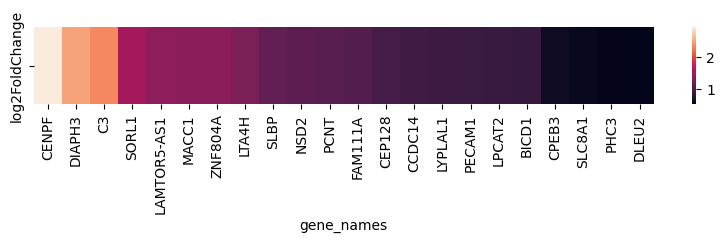

In [38]:
plt.figure(figsize=(10, 1))
sns.heatmap(macrophages_obese.T)
plt.savefig("/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/macrophages_obesity.svg", bbox_inches="tight")

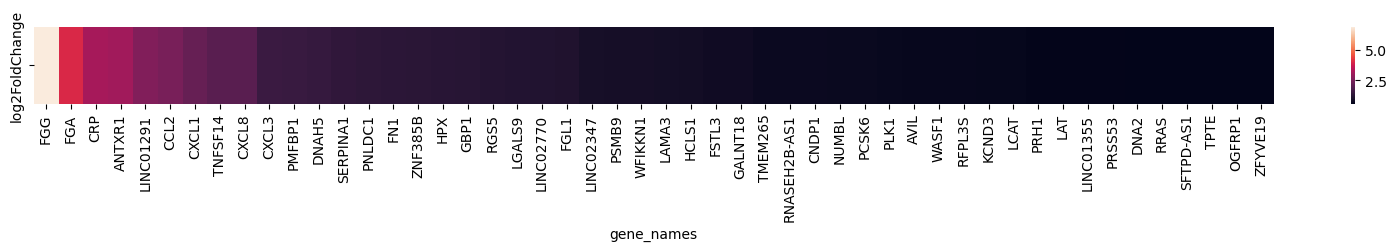

In [ ]:
plt.figure(figsize=(20, 1))
sns.heatmap(pd.DataFrame(result_acinar_bmi.de_by_level["obese"].sort_values(by="log2FoldChange", ascending=False).query('padj<0.05 and log2FoldChange>0').sort_values(by='log2FoldChange', ascending=False)[:50].log2FoldChange).T)
plt.savefig("/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/acinar_obesity_genes.svg", bbox_inches="tight")

In [41]:
result_acinar_bmi.significant_log2fc().sort_values(by="obese", ascending=False)

test_level,obese,overweight,underweight
gene_names,,,
FGG,6.906913,7.131951,4.388114
FGA,4.024627,4.130291,NaN
CRP,3.177712,4.543506,NaN
ANTXR1,3.093642,NaN,NaN
LINC01291,2.631526,2.902709,NaN
...,...,...,...
ZNF329,NaN,NaN,0.860493
ZNF395,NaN,NaN,-0.557207
ZNF684,NaN,NaN,0.713333


In [49]:
ora_acinar = pseudobulk_ora(result_acinar_bmi, test_level="obese", direction="up")

obese: 141 significant genes


In [50]:
acinar_sig = ora_acinar.results.query('`Adjusted P-value`<0.05 and Gene_set != "MSigDB_Hallmark_2020"')

In [58]:
acinar_sig.Genes.str.split(';')

test_level      
obese       992                           [CXCL8, CCL2, CXCL1, CXCL3]
            993                           [CXCL8, CCL2, CXCL1, CXCL3]
            1154    [FGA, HPX, SERPINA1, FGL1, FGG, LAMA3, FN1, LG...
            1155                            [FGA, SERPINA1, FGG, FN1]
            1253     [CXCL8, CCL2, CXCL1, SUGT1, CXCL3, ANTXR1, GBP1]
            1254                 [CXCL8, TNFSF14, CCL2, CXCL1, CXCL3]
            1255                    [CXCL8, LAMA3, FN1, CXCL1, CXCL3]
            1256                  [CXCL8, TNFSF14, CXCL1, CXCL3, LAT]
            1257                       [CXCL8, WIPF1, FN1, CCL2, LAT]
            1258                          [CXCL8, CCL2, CXCL1, CXCL3]
            1259                          [CXCL8, CCL2, CXCL1, CXCL3]
            1260                            [POMT2, POGLUT1, GALNT18]
Name: Genes, dtype: object

<Figure size 800x200 with 0 Axes>

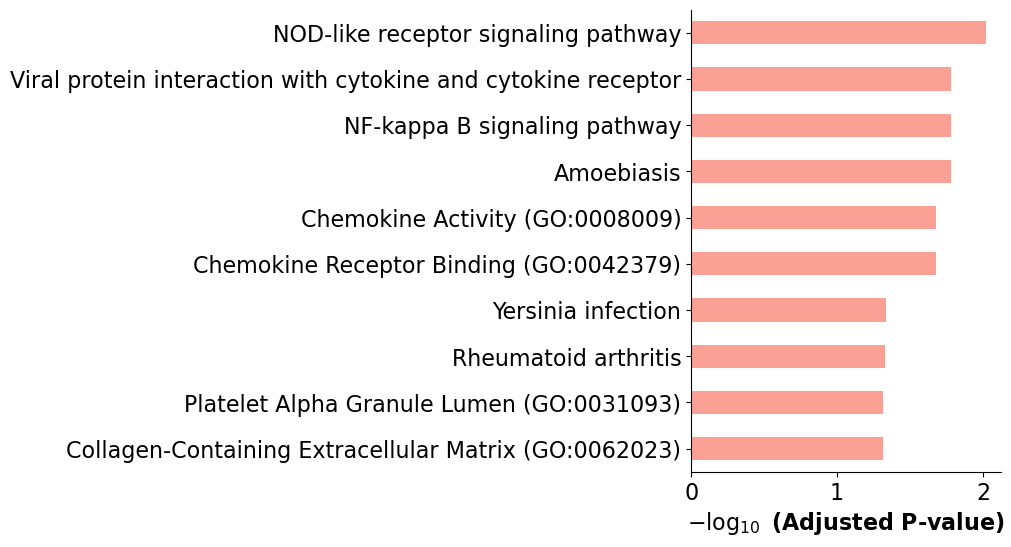

In [56]:
plt.figure(figsize=(8, 2))
gp.barplot(acinar_sig)
plt.savefig("/lustre/groups/ml01/workspace/hpca/hpca_downstream/metadata_analysis/acinar_obesity.svg")

In [18]:
ora_macrophage = pseudobulk_ora(result_macrophage_bmi, test_level="obese", direction="up")

obese: 22 significant genes


In [32]:
beta_age = pseudobulk_ora(result, direction="up")

(50.0, 60.0): 60 significant genes
(40.0, 50.0): 28 significant genes
(60.0, 70.0): 9 significant genes
(20.0, 30.0): 121 significant genes
(70.0, 80.0): 64 significant genes
(5.0, 15.0): 17 significant genes
(1.0, 5.0): 83 significant genes
(15.0, 20.0): 0 significant genes
  skip ORA (< 5 genes)


In [34]:
beta_age.results_by_level['(1.0, 5.0)'].query('`Adjusted P-value`<0.05')[:20]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,test_level,n_input_genes
0,GO_Biological_Process_2023,Cilium Organization (GO:0044782),1.087006e-08,0.000008,0,0,14.109589,258.731111,IFT74;INTU;IFT140;IQUB;CCDC65;KIFAP3;CLUAP1;PI...,"(1.0, 5.0)",83
1,GO_Biological_Process_2023,Plasma Membrane Bounded Cell Projection Assemb...,6.936413e-08,0.000027,0,0,11.473412,189.126525,ITGB1;IFT74;INTU;IFT140;IQUB;CCDC65;EZR;CLUAP1...,"(1.0, 5.0)",83
2,GO_Biological_Process_2023,Cilium Assembly (GO:0060271),2.773051e-07,0.000071,0,0,11.567085,174.641556,IFT74;INTU;IFT140;IQUB;CCDC65;RPGRIP1L;CLUAP1;...,"(1.0, 5.0)",83
3,GO_Biological_Process_2023,Organelle Assembly (GO:0070925),2.891479e-06,0.000555,0,0,8.605946,109.758019,IFT74;INTU;IFT140;VPS4B;IQUB;CCDC65;CLUAP1;PIB...,"(1.0, 5.0)",83
4,GO_Biological_Process_2023,Positive Regulation Of Cell Migration (GO:0030...,8.660243e-06,0.001330,0,0,8.759434,102.106685,ITGB1;SPAG9;TJP1;APC;GLIPR2;ROCK2;MIA3;DOCK1,"(1.0, 5.0)",83
5,GO_Biological_Process_2023,Actomyosin Structure Organization (GO:0031032),2.102688e-04,0.026914,0,0,15.088608,127.757108,ITGB1;TJP1;EPB41L5;ROCK2,"(1.0, 5.0)",83
6,GO_Biological_Process_2023,Regulation Of Cellular Component Biogenesis (G...,3.862457e-04,0.030871,0,0,23.706618,186.311180,TJP1;ROCK2;EZR,"(1.0, 5.0)",83
7,GO_Biological_Process_2023,Positive Regulation Of Protein Localization To...,4.019687e-04,0.030871,0,0,88.567901,692.524502,ROCK2;EZR,"(1.0, 5.0)",83
8,GO_Biological_Process_2023,Positive Regulation Of Protein Localization To...,4.019687e-04,0.030871,0,0,88.567901,692.524502,ROCK2;EZR,"(1.0, 5.0)",83
9,GO_Biological_Process_2023,Regulation Of Protein Localization To Early En...,4.019687e-04,0.030871,0,0,88.567901,692.524502,ROCK2;EZR,"(1.0, 5.0)",83


In [35]:
beta_age.results_by_level['(5.0, 15.0)'].query('`Adjusted P-value`<0.05')[:20]

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,test_level,n_input_genes
0,GO_Biological_Process_2023,Regulation Of Insulin Secretion (GO:0050796),0.000037,0.010110,0,0,56.912698,580.719664,BRSK2;CELA2A;GHRL,"(5.0, 15.0)",17
1,GO_Biological_Process_2023,Heterophilic Cell-Cell Adhesion Via Plasma Mem...,0.000617,0.048062,0,0,63.848889,471.924417,CXADR;NECTIN1,"(5.0, 15.0)",17
2,GO_Biological_Process_2023,Actin Cytoskeleton Reorganization (GO:0031532),0.000784,0.048062,0,0,56.321569,402.772239,BRSK2;CXADR,"(5.0, 15.0)",17
3,GO_Biological_Process_2023,Cell Junction Organization (GO:0034330),0.001071,0.048062,0,0,47.853333,327.268104,PKHD1;CXADR,"(5.0, 15.0)",17
4,GO_Biological_Process_2023,Cell-Cell Junction Organization (GO:0045216),0.001287,0.048062,0,0,43.490909,289.456457,PKHD1;CXADR,"(5.0, 15.0)",17
5,GO_Biological_Process_2023,Synapse Assembly (GO:0007416),0.001402,0.048062,0,0,41.594203,273.272809,FZD1;SHANK2,"(5.0, 15.0)",17
6,GO_Biological_Process_2023,Regulation Of Cell Population Proliferation (G...,0.002119,0.048062,0,0,8.894950,54.762808,PKHD1;GHRL;ULK1;SHANK2,"(5.0, 15.0)",17
7,GO_Biological_Process_2023,Autocrine Signaling (GO:0035425),0.003143,0.048062,0,0,449.812500,2592.078998,FZD1,"(5.0, 15.0)",17
8,GO_Biological_Process_2023,Positive Regulation Of Growth Hormone Secretio...,0.003927,0.048062,0,0,337.343750,1868.817599,GHRL,"(5.0, 15.0)",17
9,GO_Biological_Process_2023,Medium-Chain fatty-acyl-CoA Metabolic Process ...,0.003927,0.048062,0,0,337.343750,1868.817599,NUDT19,"(5.0, 15.0)",17


In [25]:
ora_macrophage.results.query('`Adjusted P-value`<0.07')[:20]

Gene_set  \
test_level                                  
obese      0   GO_Biological_Process_2023   
           1   GO_Biological_Process_2023   
           2   GO_Biological_Process_2023   
           3   GO_Biological_Process_2023   
           4   GO_Biological_Process_2023   
           5   GO_Biological_Process_2023   
           6   GO_Biological_Process_2023   
           7   GO_Biological_Process_2023   
           8   GO_Biological_Process_2023   
           9   GO_Biological_Process_2023   
           10  GO_Biological_Process_2023   
           11  GO_Biological_Process_2023   
           12  GO_Biological_Process_2023   
           13  GO_Biological_Process_2023   
           14  GO_Biological_Process_2023   
           15  GO_Biological_Process_2023   
           16  GO_Biological_Process_2023   
           17  GO_Biological_Process_2023   
           18  GO_Biological_Process_2023   
           19  GO_Biological_Process_2023   

                                                            Term   P-value  \
test_level                                                                   
obese      0   Regulation Of Receptor-Mediated Endocytosis (G...  0.000879   
           1   Positive Regulation Of Intracellular Transport...  0.001046   
           2   Positive Regulation Of Receptor-Mediated Endoc...  0.001046   
           3     Positive Regulation Of Endocytosis (GO:0045807)  0.003580   
           4   Negative Regulation Of Protein Serine/Threonin...  0.004349   
           5   Positive Regulation Of Protein Localization (G...  0.005064   
           6   Negative Regulation Of Protein Kinase Activity...  0.005188   
           7               Neutrophil Extravasation (GO:0072672)  0.005338   
           8   Negative Regulation Of Amide Metabolic Process...  0.005697   
           9   mRNA 3'-End Processing By Stem-Loop Binding An...  0.006669   
           10  Cap-Dependent Translational Initiation (GO:000...  0.006669   
           11  Regulation Of Striated Muscle Tissue Developme...  0.006669   
           12    Glomerulus Vasculature Development (GO:0072012)  0.006669   
           13  Vascular Associated Smooth Muscle Contraction ...  0.006669   
           14  Negative Regulation Of Phospholipase Activity ...  0.006669   
           15  Positive Regulation Of Apoptotic Cell Clearanc...  0.006669   
           16  Regulation Of Apoptotic Cell Clearance (GO:200...  0.006669   
           17         Cellular Response To Caffeine (GO:0071313)  0.007997   
           18  Positive Regulation Of Protein Localization To...  0.007997   
           19                  Response To Caffeine (GO:0031000)  0.007997   

               Adjusted P-value  Old P-value  Old adjusted P-value  \
test_level                                                           
obese      0           0.061577            0                     0   
           1           0.061577            0                     0   
           2           0.061577            0                     0   
           3           0.061577            0                     0   
           4           0.061577            0                     0   
           5           0.061577            0                     0   
           6           0.061577            0                     0   
           7           0.061577            0                     0   
           8           0.061577            0                     0   
           9           0.061577            0                     0   
           10          0.061577            0                     0   
           11          0.061577            0                     0   
           12          0.061577            0                     0   
           13          0.061577            0                     0   
           14          0.061577            0                     0   
           15          0.061577            0                     0   
           16          0.061577            0                     

In [13]:
result_macrophage_bmi.de_by_level["obese"].sort_values(by="log2FoldChange", ascending=False).query('padj<0.05').sort_values(by='log2FoldChange')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,contrast
gene_names,,,,,,,,
SHB,5.212291,-1.710665,0.348284,-4.911690,9.029469e-07,0.001592,SHB,obese vs normal
PAPSS2,23.740836,-1.672434,0.403688,-4.142886,3.429627e-05,0.014223,PAPSS2,obese vs normal
STAT4,6.012273,-1.661910,0.483221,-3.439232,5.833681e-04,0.049547,STAT4,obese vs normal
CYTIP,4.122812,-1.542545,0.382040,-4.037651,5.398918e-05,0.016570,CYTIP,obese vs normal
NLRP3,5.464431,-1.441547,0.378910,-3.804455,1.421167e-04,0.024641,NLRP3,obese vs normal
...,...,...,...,...,...,...,...,...
LAMTOR5-AS1,3.893002,1.390977,0.341002,4.079090,4.521228e-05,0.015942,LAMTOR5-AS1,obese vs normal
SORL1,8.994854,1.504703,0.433065,3.474539,5.117325e-04,0.049547,SORL1,obese vs normal
C3,7.211891,2.344100,0.577513,4.058952,4.929341e-05,0.016295,C3,obese vs normal


## More examples

```python
result = pseudobulk_de(adata, "Alpha Cell", "BMI", ref_level="normal")
ora = pseudobulk_ora(result, test_level="obese", direction="up")
ora.top_terms()
ora.save()
```
